# Xmatch con TESS

We analyzed the distribution of the closest and farthest counterparts in cases where two matches were found. Additionally, we examined the galactic distribution of stars with two counterparts.

Based on the distance distribution and the galactic distribution of double matches, the vast majority are located in the densest regions, so it is expected to have some degree of crowding.

Next, we assigned a flag to indicate the number of counterparts and retained the multiple TIC matches.

Finally, we considered the closest star as the original TIC source.

A total of 22 stars were found to be duplicated and have an identifier in 2MASS. In the worst-case scenario, up to 4% of the multiple matches could be contaminated.

In [97]:
from astroquery.vizier import Vizier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:


v = Vizier(row_limit=-1)
catalogs = v.get_catalogs("J/A+A/704/A155")
table = catalogs[0]

df_candidates = table.to_pandas()
labels = catalogs[1].to_pandas()
labels = labels.loc[labels["label"]<=12]
df_candidates.rename(columns={"RA_ICRS": "ra","DE_ICRS":"dec"}, inplace=True)



In [99]:
parental_catalog = pd.read_csv("~/nico/Data/Masivas/Data_OB_stars/resultados_V2/Discussion/Masivas_untilG12_Summary.csv")
parental_catalog.rename(columns={"source_id": "GaiaDR3"}, inplace=True)
parental_catalog = parental_catalog[['GaiaDR3','ra',"dec","skiff_type_list"]]
labels = labels.merge(parental_catalog,on="GaiaDR3")

/tmp/ipykernel_134499/784748606.py:1: DtypeWarning: Columns (4,11,12,14,72) have mixed types. Specify dtype option on import or set low_memory=False.
  parental_catalog = pd.read_csv("~/nico/Data/Masivas/Data_OB_stars/resultados_V2/Discussion/Masivas_untilG12_Summary.csv")


In [100]:
main_catalog = pd.concat([labels,df_candidates])

In [101]:
from astropy.table import Table
from astroquery.xmatch import XMatch
from astropy.coordinates import SkyCoord
import astropy.units as u

cat_astropy = Table.from_pandas(main_catalog[["GaiaDR3", "ra", "dec"]])

  # XMatch con TIC V8
result = XMatch.query(
      cat1=cat_astropy,
      cat2="vizier:IV/38/tic",
      max_distance=2 * u.arcsec,
      colRA1="ra",
      colDec1="dec"
  )

In [102]:
df = result.to_pandas()

In [103]:
coord = SkyCoord(ra=df["ra"].values, dec=df["dec"].values, unit=(u.deg, u.deg)).galactic
candidates_l_rad = coord.l.radian
candidates_l_rad[candidates_l_rad > np.pi] -= 2. * np.pi
candidates_b_rad = coord.b.radian

df["l"] = candidates_l_rad*u.radian.to(u.deg)
df["b"] = candidates_b_rad*u.radian.to(u.deg)

In [104]:
df_singled = df[df['GaiaDR3'].map(df['GaiaDR3'].value_counts()) == 1].reset_index(drop=True)
df_duplicated = df[df['GaiaDR3'].map(df['GaiaDR3'].value_counts()) == 2].reset_index(drop=True)
df_triplicated = df[df['GaiaDR3'].map(df['GaiaDR3'].value_counts()) == 3].reset_index(drop=True)


In [105]:
df_duplicated["nearest"] = (df_duplicated.groupby("GaiaDR3")["angDist"]
                                    .transform(lambda x: (x == x.min()).astype(int)))


In [106]:
#singled, duplicated,triplicated
len(df_singled.drop_duplicates(subset="GaiaDR3")),len(df_duplicated.drop_duplicates(subset="GaiaDR3")),len(df_triplicated.drop_duplicates(subset="GaiaDR3"))

(13018, 448, 16)

<Axes: xlabel='angDist', ylabel='Count'>

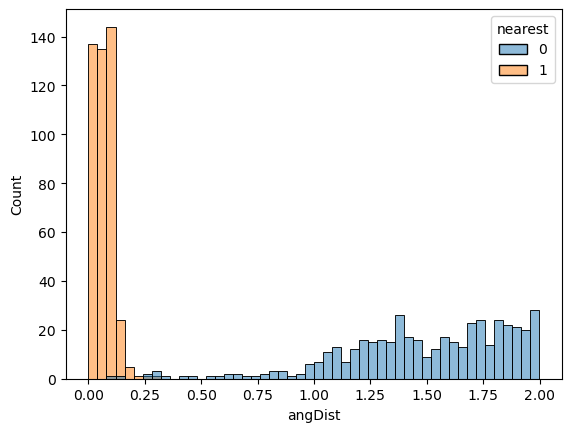

In [107]:
sns.histplot(data=df_duplicated,x="angDist",hue="nearest",bins=50)

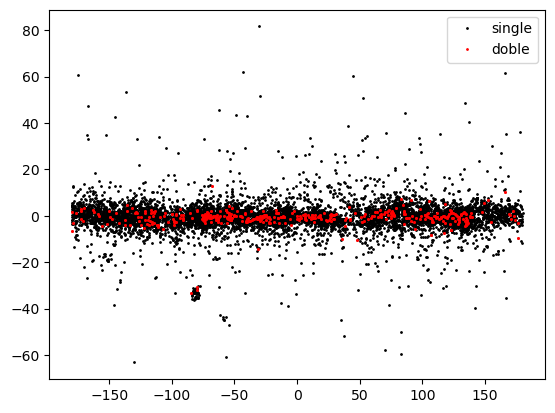

In [108]:
plt.plot(df_singled["l"],df_singled["b"],"k.",ms=2,label='single')
plt.plot(df_duplicated["l"],df_duplicated["b"],"r.",ms=2,label='doble')
plt.legend()

In [109]:
df["num_counterparts"] = df["GaiaDR3"].map(df["GaiaDR3"].value_counts())


In [110]:
df["TIC_multiple_counterpart"] = df["GaiaDR3"].map(df.groupby("GaiaDR3")["TIC"].unique())

In [111]:
len(df) - len(df.sort_values(by="angDist").drop_duplicates(subset="GaiaDR3").reset_index(drop=True))

480

In [112]:
df = df.sort_values(by="angDist").drop_duplicates(subset="GaiaDR3").reset_index(drop=True)

In [113]:
df[df["TIC_multiple_counterpart"].str.len() >1]

,angDist,GaiaDR3,ra,dec,TIC,RAdeg,DEdeg,HIP,TYC,UCAC4,...,E(B-V),s_E(B-V),e_Dist,E_Dist,RAOdeg,DEOdeg,l,b,num_counterparts,TIC_multiple_counterpart
0,0.000086,3053964194074476800,112.036878,-7.672159,5928663,112.036878,-7.672159,0,,412-031945,...,NaN,NaN,NaN,NaN,112.036878,-7.672159,-136.027571,4.577022,2,"[5928663, 753475364]"
15,0.001615,4098272263604236416,275.592973,-14.619030,118466552,275.592973,-14.619030,0,5689-00589-1,377-108012,...,NaN,NaN,NaN,NaN,275.592973,-14.619030,16.645585,-0.352979,2,"[118466552, 1646097795]"
33,0.002311,4658194157700347648,79.549730,-69.217575,179209305,79.549729,-69.217576,0,,,...,NaN,NaN,NaN,NaN,79.549729,-69.217576,-80.057814,-33.454321,3,"[179209305, 680189445, 680189428]"
41,0.002538,468479678148636800,59.960147,55.435873,72608740,59.960147,55.435873,0,3721-00569-1,728-030844,...,0.5877,0.0211,325.920013,398.709991,59.960147,55.435873,147.502076,1.822128,2,"[72608740, 647531056]"
58,0.003126,5312174023128931072,143.749718,-53.053537,299594308,143.749720,-53.053537,0,,185-037760,...,NaN,NaN,NaN,NaN,143.749720,-53.053537,-84.096522,-0.815946,2,"[299594308, 859505577]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13379,0.188585,5882141502118595328,233.332603,-58.660181,284265262,233.332640,-58.660132,0,8707-00312-1,157-143091,...,NaN,NaN,NaN,NaN,233.332603,-58.660181,-37.322981,-2.139130,2,"[284265262, 1136368212]"
13380,0.189431,5350359752713348480,161.126462,-59.623999,458855620,161.126558,-59.624019,0,8626-02824-1,152-052932,...,NaN,NaN,NaN,NaN,161.126464,-59.624000,-72.493233,-0.608729,2,"[458855620, 934631356]"
13440,0.227276,4313259870958222848,287.891057,12.529599,396525485,287.891104,12.529643,0,1049-00950-1,513-095706,...,NaN,NaN,NaN,NaN,287.891058,12.529600,46.357201,1.302198,2,"[396525485, 520716665]"
13457,0.259960,1972509777055312384,320.959047,47.164533,139258713,320.959128,47.164579,105640,3594-01695-1,686-101182,...,NaN,NaN,NaN,NaN,320.959052,47.164543,90.557917,-2.234355,2,"[139258713, 2008877991]"


In [114]:
df = df.sort_values(by="angDist").drop_duplicates(subset="GaiaDR3").reset_index(drop=True)

In [115]:
df.to_csv("catalogs/1_MassiveXTessV8.csv",index=False)

# Download light curves from TIC information

## Search TESS-SPOC

In [116]:
from astroquery.mast import Observations
import pandas as pd
from astropy.io import fits
import re

### Masivas x TESS

In [117]:
df = pd.read_csv("catalogs/1_MassiveXTessV8.csv")

In [83]:
tic_ids = df["TIC"].values

In [85]:
from astropy.table import vstack

def get_tess_spoc_products(tic_ids, batch_size=50):
    all_products = []
    batches = [tic_ids[i:i+batch_size] for i in range(0, len(tic_ids), batch_size)]

    for k, batch in enumerate(batches):
        print(f"Batch {k+1}/{len(batches)}...", end="\r")
        try:
            obs = Observations.query_criteria(
                provenance_name="TESS-SPOC",
                target_name=batch,
                dataproduct_type='TIMESERIES'
            )
            if len(obs) == 0:
                continue
            products = Observations.get_product_list(obs)

            # Filtra solo _lc.fits
            lc_mask = ['_lc.fits' in p for p in products['productFilename']]
            lc_products = products[lc_mask]

            if len(lc_products) > 0:
                all_products.append(lc_products)
        except Exception as e:
            print(f"\nError batch {k+1}: {e}")

    print(f"\nListo: {len(all_products)} batches con datos")
    return vstack(all_products) if all_products else None

data_products = get_tess_spoc_products(tic_ids, batch_size=50)



Batch 270/270...
Listo: 270 batches con datos


In [120]:
# Convertir a pandas y extraer TIC, sector, filename
data_products_df = data_products.to_pandas()
data_products_df["TIC"] = data_products_df["productFilename"].str.split("_").str[4].str.split("-").str[0].astype(int)
data_products_df["sector"] = data_products_df["productFilename"].str.split("_").str[4].str.split("-").str[1].str[1:].astype(int)
data_products_df = data_products_df[["TIC", "sector", "dataURI", "productFilename"]]

# Guardar CSV con una fila por lightcurve
data_products_df.to_csv("catalogs/2_MassiveXTessV8_LC.csv", index=False)

# Agregar sector_list y filenames al catálogo original
tic_sectors = (
    data_products_df.groupby("TIC")
    .agg(
        sector_list=("sector", list),
        filenames=("productFilename", list)
    )
    .reset_index()
)

df = df.merge(tic_sectors, how="left", on="TIC")
df.to_csv("catalogs/1_MassiveXTessV8.csv", index=False)

print(f"Estrellas con datos: {df['sector_list'].notna().sum()} / {len(df)}")
print(f"Total lightcurves: {len(data_products_df)}")







Estrellas con datos: 5369 / 13482
Total lightcurves: 13483


## Download parallel LC

In [121]:
import pandas as pd
from astroquery.mast import Observations
import os
import re

In [122]:
data_products_df =  pd.read_csv("catalogs/2_MassiveXTessV8_LC.csv")

In [123]:
  import os
  import concurrent.futures
  from astroquery.mast import Observations

  DIR = "download_paralell"
  os.makedirs(DIR, exist_ok=True)

  def download_file(dataURI):
      filename = dataURI.split('/')[-1]
      file_path = os.path.join(DIR, filename)
      if os.path.isfile(file_path):
          return f"EXISTS: {filename}"
      try:
          Observations.download_file(dataURI, local_path=file_path)
          return f"OK: {filename}"
      except Exception as e:
          return f"ERROR: {filename} — {e}"

  data_products_df = pd.read_csv("catalogs/2_MassiveXTessV8_LC.csv")
  uris = data_products_df["dataURI"].tolist()

  with concurrent.futures.ThreadPoolExecutor(max_workers=25) as executor:
      futures = {executor.submit(download_file, uri): uri for uri in uris}
      for i, future in enumerate(concurrent.futures.as_completed(futures)):
          print(f"[{i+1}/{len(uris)}] {future.result()}", end="\r")

  print("\nDescarga completada.")



[13483/13483] EXISTS: hlsp_tess-spoc_tess_phot_0000000385454053-s0063_tess_v1_lc.fits
Descarga completada.


## Revisar si se descargaron todos los datos y esta a corde con lo que esperamos de los catalogos

In [124]:
import pandas as pd
import os
from astropy.io import fits
import seaborn as sns
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from pandarallel import pandarallel
pandarallel.initialize(nb_workers=30, progress_bar=True)

INFO: Pandarallel will run on 30 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [125]:
  df = pd.read_csv("catalogs/1_MassiveXTessV8.csv")
  data_products_df = pd.read_csv("catalogs/2_MassiveXTessV8_LC.csv")

  # Filtra solo _lc.fits
  data_products_df_lc = data_products_df[data_products_df["productFilename"].str.endswith("_lc.fits")].reset_index(drop=True)

  # Archivos descargados
  downloaded = set(os.listdir("download_paralell/"))
  expected = set(data_products_df_lc["productFilename"])
  missing = expected - downloaded

  print(f"Esperadas : {len(expected)}")
  print(f"Descargadas: {len(downloaded)}")
  print(f"Faltantes : {len(missing)}")
  if missing:
      print("Ejemplos faltantes:", list(missing)[:5])

  # Estrellas únicas con datos SPOC
  df["sector_list"] = df["sector_list"].apply(
      lambda x: list(map(int, re.findall(r"\d+", x))) if isinstance(x, str) else x
  )
  estrellas_con_datos = df["sector_list"].notna().sum()
  tics_unicos = data_products_df_lc["TIC"].nunique()
  print(f"\nEstrellas con sector_list: {estrellas_con_datos}")
  print(f"TICs únicos en productos : {tics_unicos}")
  print(f"Match: {estrellas_con_datos == tics_unicos}")

  print(f"\nSector máximo: {data_products_df_lc['sector'].max()}")
  print(f"Sectores únicos: {sorted(data_products_df_lc['sector'].unique())}")


Esperadas : 13483
Descargadas: 13484
Faltantes : 0

Estrellas con sector_list: 5369
TICs únicos en productos : 5369
Match: True

Sector máximo: 84
Sectores únicos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84]


## Revisar cuantas fuentes hay en la apertura

In [25]:
import pandas as pd
import os
import re

In [26]:
df = pd.read_csv("catalogs/2_MassiveXTessV8_LC.csv")
df_parental = pd.read_csv("catalogs/1_MassiveXTessV8.csv")

In [27]:

# Define el directorio
directorio = "CheckAperture/tpfplotter/GAIA_TIC_MASSIVE_STARS/"

# Obtiene la lista de archivos y carpetas dentro del directorio
archivos = os.listdir(directorio)
df_dat = pd.DataFrame(archivos,columns=["TPfPloter"])
df_dat["TIC"] = df_dat["TPfPloter"].str.split("_").str[1].str[3:]
df_dat["sector_TPfPloter"] = df_dat["TPfPloter"].str.split("_").str[-1].str[1:-4]
df_dat["TIC"] = df_dat["TIC"].astype(int)
df_parental = df_parental.merge(df_dat,how="left",on="TIC")
df_parental = df_parental.loc[df_parental["sector_list"].notna()]
df_parental_to_dowload = df_parental.loc[df_parental["TPfPloter"].isna()].reset_index(drop=True)


In [152]:
df_parental_to_dowload

,angDist,GaiaDR3,ra,dec,TIC,RAdeg,DEdeg,HIP,TYC,UCAC4,...,RAOdeg,DEOdeg,l,b,num_counterparts,TIC_multiple_counterpart,sector_list,filenames,TPfPloter,sector_TPfPloter
0,0.007514,463682577633083008,47.553593,61.951369,81821733,47.553598,61.951369,0,4053-01564-1,760-025033,...,47.553594,61.951369,138.483405,3.344746,1,[81821733],"[58, 59]",['hlsp_tess-spoc_tess_phot_0000000081821733-s0...,NaN,NaN
1,0.008192,4098093077571330816,274.560388,-15.581712,113821744,274.560389,-15.581711,0,6265-00725-1,373-123540,...,274.560388,-15.581712,15.326503,0.072035,1,[113821744],[80],['hlsp_tess-spoc_tess_phot_0000000113821744-s0...,NaN,NaN
2,0.008221,4105033087572782336,281.219256,-14.353120,426554741,281.219257,-14.353118,91982,5704-00919-1,379-127263,...,281.219256,-14.353120,19.388281,-5.069143,1,[426554741],[80],['hlsp_tess-spoc_tess_phot_0000000426554741-s0...,NaN,NaN
3,0.011195,254502238495700736,72.916727,45.766826,21240658,72.916723,45.766828,0,NaN,679-030605,...,72.916727,45.766826,160.128819,0.964558,1,[21240658],[73],['hlsp_tess-spoc_tess_phot_0000000021240658-s0...,NaN,NaN
4,0.011573,523454469262359808,17.507256,64.271616,52951593,17.507261,64.271618,0,4038-01421-1,772-008188,...,17.507256,64.271616,124.948421,1.472682,1,[52951593],[78],['hlsp_tess-spoc_tess_phot_0000000052951593-s0...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,0.254607,5407087989994899200,150.635903,-48.862054,136216759,150.636011,-48.862056,49201,8190-00465-1,206-036943,...,150.635907,-48.862054,-83.422098,5.173113,1,[136216759],[63],['hlsp_tess-spoc_tess_phot_0000000136216759-s0...,NaN,NaN
446,0.272929,4268516314747516800,285.683632,2.338945,228676990,285.683615,2.339019,0,0466-01856-1,462-083361,...,285.683631,2.338947,36.302168,-1.444280,1,[228676990],[80],['hlsp_tess-spoc_tess_phot_0000000228676990-s0...,NaN,NaN
447,0.280656,1275657105697701888,226.618977,28.983760,229898846,226.618978,28.983838,73931,2030-00744-1,595-052202,...,226.618977,28.983763,44.515458,60.250033,1,[229898846],"[77, 78]",['hlsp_tess-spoc_tess_phot_0000000229898846-s0...,NaN,NaN
448,0.283373,531748768362534784,20.457269,67.845623,352677751,20.457384,67.845557,0,4297-00910-1,790-003959,...,20.457276,67.845622,125.801437,5.143358,1,[352677751],[79],['hlsp_tess-spoc_tess_phot_0000000352677751-s0...,NaN,NaN


## Descarga de codigo fuente por problemas al correrlo en linea de comando

In [5]:
import numpy as np
import argparse

from lightkurve import search_targetpixelfile
from lightkurve import search_tesscut
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colorbar import Colorbar
from matplotlib import patches
import matplotlib.gridspec as gridspec
# from bokeh.io import export_png
# from bokeh.io.export import get_screenshot_as_png

from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u
from astropy.visualization import SqrtStretch,LinearStretch
import astropy.visualization as stretching
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.table import Table, Column, MaskedColumn
from astropy.io import ascii
from astroquery.mast import Catalogs
from astroquery.simbad import Simbad
Simbad.add_votable_fields('pmra', 'pmdec')
from astroquery.gaia import Gaia
from astroquery.vizier import Vizier
Vizier.ROW_LIMIT = -1
from astropy.io import fits

import pandas as pd
import os
import re

from pandarallel import pandarallel
# Inicializa pandarallel con 30 núcleos
pandarallel.initialize(nb_workers=30, progress_bar=True)

INFO: Pandarallel will run on 30 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [6]:
def plot_orientation(tpf, ax=None):
    if ax is None:
        ax = plt.gca()
    mean_tpf = np.nanmean(tpf.flux, axis=0)
    nx, ny = mean_tpf.shape
    x0 = tpf.column + int(0.2 * nx) + 0.5
    y0 = tpf.row + int(0.2 * ny) + 0.5

    ra, dec = tpf.get_coordinates()
    ra00, dec00 = ra[0][0][0], dec[0][0][0]
    ra10, dec10 = ra[0][0][-1], dec[0][0][-1]
    cosdec = np.cos(np.deg2rad(0.5 * (dec10 + dec00)))
    theta = np.arctan((dec10 - dec00) / (cosdec * (ra00 - ra10)))
    if (ra10 - ra00) < 0.0:
        theta += np.pi
    if abs(np.rad2deg(theta)) < 30:
        x0 -= 0.08 * nx
        y0 -= 0.08 * ny
    for label, ang in (('E', theta), ('N', theta + 0.5 * np.pi)):
        x1, y1 = np.cos(ang), np.sin(ang)
        ax.arrow(x0, y0, x1, y1, head_width=0.2, color='white')
        ax.text(x0 + 1.6 * x1, y0 + 1.6 * y1, label,
                color='white', ha='center', va='center')


def _query_gaia_sources(tpf, mag):
    c1 = SkyCoord(tpf.ra, tpf.dec, frame='icrs', unit='deg')
    pix_scale = 21.0
    gaia_cat = "I/355/gaiadr3"
    result = Vizier.query_region(
        c1, catalog=[gaia_cat],
        radius=Angle(np.max(tpf.shape[1:]) * pix_scale, "arcsec"),
    )[gaia_cat].to_pandas()
    result = result[result.Gmag < mag + 6].reset_index(drop=True)

    year = ((tpf.time[0].jd - 2457206.375) * u.day).to(u.year)
    pmra = (np.nan_to_num(result.pmRA.values) * u.mas / u.year * year).to(u.deg).value
    pmdec = (np.nan_to_num(result.pmDE.values) * u.mas / u.year * year).to(u.deg).value
    result.RA_ICRS += pmra
    result.DE_ICRS += pmdec
    return result


def run_locallytpfpploter(
    tic, gaia_id, sector, mag,
    pdf_dir='CheckAperture/tpfplotter/TPF_Gaia_MASSIVE_STARS',
    dat_dir='CheckAperture/tpfplotter/GAIA_TIC_MASSIVE_STARS',
):
    os.makedirs(pdf_dir, exist_ok=True)
    os.makedirs(dat_dir, exist_ok=True)

    # sector puede venir como int, float, lista real, o string tipo "[80]" / "[43, 44, 45]"
    import ast
    if isinstance(sector, str):
        try:
            sector = ast.literal_eval(sector)
        except Exception:
            pass
    if hasattr(sector, '__iter__') and not isinstance(sector, str):
        sector = list(sector)[0]
    sec = int(float(sector))
    tpf = search_targetpixelfile("TIC " + str(tic), mission='TESS', sector=sec).download()

    mean_tpf = np.nanmean(tpf.flux, axis=0)
    nx, ny = mean_tpf.shape
    division = int(np.log10(np.nanmax(mean_tpf.value)))
    image = mean_tpf / 10 ** division

    fig = plt.figure(figsize=(6.93, 5.5))
    gs = gridspec.GridSpec(1, 3, height_ratios=[1], width_ratios=[1, 0.05, 0.01])
    gs.update(left=0.05, right=0.95, bottom=0.12, top=0.95, wspace=0.01, hspace=0.03)
    ax1 = plt.subplot(gs[0, 0])

    norm = ImageNormalize(stretch=stretching.LogStretch())
    splot = ax1.imshow(
        image.value, norm=norm,
        extent=[tpf.column + 0.5, tpf.column + ny + 0.5,
                tpf.row + 0.5, tpf.row + nx + 0.5],
        origin='lower', zorder=0,
    )

    aperture_mask = tpf.pipeline_mask
    maskcolor = 'tomato'
    for i, j in zip(*np.where(aperture_mask)):
        xy = (j + tpf.column + 0.5, i + tpf.row + 0.5)
        ax1.add_patch(patches.Rectangle(xy, 1, 1, color=maskcolor, fill=True, alpha=0.4))
        ax1.add_patch(patches.Rectangle(xy, 1, 1, color=maskcolor, fill=False, alpha=1, lw=2))

    result = _query_gaia_sources(tpf, mag)
    radecs = np.vstack([result['RA_ICRS'], result['DE_ICRS']]).T
    coords = tpf.wcs.all_world2pix(radecs, 0.5)

    sources = np.asarray(result['Source'].values, dtype=np.int64)
    gid = np.int64(gaia_id)
    target_idx = np.where(sources == gid)[0]

    if target_idx.size == 0:
        print(f"\t WARNING: Gaia ID {gaia_id} not found in query "
            f"(mag<{mag+6}). Using closest source as reference.")
        cx = tpf.column + ny / 2
        cy = tpf.row + nx / 2
        x_tmp = coords[:, 0] + tpf.column + 0.5
        y_tmp = coords[:, 1] + tpf.row + 0.5
        target_idx = np.array([np.argmin(np.hypot(x_tmp - cx, y_tmp - cy))])

    x = coords[:, 0] + tpf.column + 0.5
    y = coords[:, 1] + tpf.row + 0.5
    gaiamags = result['Gmag'].values

    size = 128.0 / 2 ** (gaiamags - mag)
    ax1.scatter(x, y, s=size, c='red', alpha=0.6, edgecolor=None, zorder=10)
    ax1.scatter(x[target_idx], y[target_idx], marker='x', c='white', s=32, zorder=11)

    maxmag = 6 + (6 % 2)
    legend_mags = np.linspace(-2, maxmag, int((maxmag + 2) / 2 + 1))
    for dm in legend_mags:
        ax1.scatter(0, 0, s=128.0 / 2 ** dm, c='red', alpha=0.6,
                    edgecolor=None, zorder=10,
                    label=r'$\Delta m=$ ' + str(int(dm)))
    ax1.legend(fancybox=True, framealpha=0.7, loc='best', fontsize=14)

    dist = np.hypot(x - x[target_idx], y - y[target_idx])
    dsort = np.argsort(dist)
    xmin, xmax = tpf.column + 0.05 * nx, tpf.column + 0.95 * nx
    ymin, ymax = tpf.row + 0.05 * ny, tpf.row + 0.95 * ny
    in_view = (x < xmax) & (x > xmin) & (y < ymax) & (y > ymin)
    for d, elem in enumerate(dsort):
        if in_view[elem]:
            ax1.text(x[elem] + 0.1, y[elem] + 0.1, str(d + 1),
                    color='white', zorder=100, fontsize=14)

    plot_orientation(tpf, ax=ax1)

    ax1.set_xlim(tpf.column + ny + 0.5, tpf.column + 0.5)
    ax1.set_ylim(tpf.row + 0.5, tpf.row + nx + 0.5)
    ax1.set_xlabel('Pixel Column Number', fontsize=16, zorder=200)
    ax1.set_ylabel('Pixel Row Number', fontsize=16, zorder=200)
    ax1.set_title(f'TIC {tic} - Sector {tpf.sector}', fontsize=16, zorder=200)

    cbax = plt.subplot(gs[0, 1])
    pos1 = cbax.get_position()
    cbax.set_position([pos1.x0 - 0.05, pos1.y0, pos1.width, pos1.height])
    cb = Colorbar(ax=cbax, mappable=splot, orientation='vertical', ticklocation='right')
    cb.set_label(r'Flux $\times 10^' + str(division) + r'$ (e$^-$/s)',
                labelpad=10, fontsize=16)

    out_pdf = os.path.join(pdf_dir, f'TPF_Gaia_TIC{tic}_S{tpf.sector}.pdf')
    plt.savefig(out_pdf)
    plt.close()
    print(f'\t --> TPF plot written in file: {out_pdf}')

    srt = np.argsort(dist)
    x_s, y_s = x[srt], y[srt]
    gaiamags_s = gaiamags[srt]
    dist_s = dist[srt]
    gaia_ids_s = sources[srt]

    xpix = np.floor(x_s - tpf.column - 0.5).astype(int)
    ypix = np.floor(y_s - tpf.row - 0.5).astype(int)
    valid = (xpix >= 0) & (xpix < ny) & (ypix >= 0) & (ypix < nx)
    inside = np.zeros(len(x_s), dtype=int)
    inside[valid] = aperture_mask[ypix[valid], xpix[valid]].astype(int)

    ids = np.arange(len(x_s)) + 1
    data = Table(
        [ids, gaia_ids_s, x_s, y_s, dist_s, dist_s * 21., gaiamags_s, inside],
        names=['# ID', 'GaiaID', 'x', 'y', 'Dist_pix', 'Dist_arcsec', 'Gmag', 'InAper'],
    )
    out_dat = os.path.join(dat_dir, f'Gaia_TIC{tic}_S{tpf.sector}.dat')
    ascii.write(data, out_dat, overwrite=True)
    print(f'\t --> Gaia close sources saved in file: {out_dat}')
    print("\t --> Done!\n")




In [7]:
df = pd.read_csv("catalogs/2_MassiveXTessV8_LC.csv")
df_parental = pd.read_csv("catalogs/1_MassiveXTessV8.csv")

In [8]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from pathlib import Path
import time
import glob
import os
import shutil
import numpy as np
import pandas as pd

PDF_DIR = 'CheckAperture/tpfplotter/TPF_Gaia_MASSIVE_STARS'
DAT_DIR = 'CheckAperture/tpfplotter/GAIA_TIC_MASSIVE_STARS'
LK_CACHE = Path.home() / '.lightkurve' / 'cache' / 'mastDownload' / 'TESS'

os.makedirs(PDF_DIR, exist_ok=True)
os.makedirs(DAT_DIR, exist_ok=True)

# ---- Limpia archivos truncados del cache de lightkurve (descargas interrumpidas) ----
def clean_truncated_cache(min_bytes=200_000):
    """Borra cualquier *_tp.fits en el cache de lightkurve menor a min_bytes (truncado)."""
    roots = [Path.home() / '.lightkurve' / 'cache' / 'mastDownload' / 'TESS',
             Path.home() / '.lightkurve' / 'cache' / 'mastDownload' / 'HLSP']
    n = 0
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob('*tp.fits'):
            try:
                if p.stat().st_size < min_bytes:
                    p.unlink()
                    n += 1
            except Exception:
                pass
        # quita dirs vacios
        for d in sorted(root.rglob('*'), reverse=True):
            if d.is_dir():
                try: d.rmdir()
                except OSError: pass
    if n:
        print(f"Cache: borrados {n} archivos truncados")

clean_truncated_cache()

# ---- Filtra TICs que ya tienen archivo .dat generado ----
archivos = os.listdir(DAT_DIR)
df_dat = pd.DataFrame(archivos, columns=["TPfPloter"])
df_dat["TIC"] = df_dat["TPfPloter"].str.split("_").str[1].str[3:].astype(int)
df_dat["sector_TPfPloter"] = df_dat["TPfPloter"].str.split("_").str[-1].str[1:-4]

df_parental = df_parental.merge(df_dat, how="left", on="TIC")
df_parental = df_parental.loc[df_parental["sector_list"].notna()]
df_parental_to_dowload = df_parental.loc[df_parental["TPfPloter"].isna()].reset_index(drop=True)

print(f"Total a procesar: {len(df_parental_to_dowload)}")


def clear_lk_cache(tic):
    """Borra archivos cacheados por lightkurve para este TIC (corruptos por descargas truncadas)."""
    if not LK_CACHE.exists():
        return
    for p in LK_CACHE.glob(f'*{tic}*'):
        try:
            shutil.rmtree(p) if p.is_dir() else p.unlink()
        except Exception:
            pass


def already_done(tic):
    """True si ya existe PDF + DAT para este TIC (cualquier sector)."""
    pdfs = glob.glob(os.path.join(PDF_DIR, f'TPF_Gaia_TIC{tic}_S*.pdf'))
    dats = glob.glob(os.path.join(DAT_DIR, f'Gaia_TIC{tic}_S*.dat'))
    return len(pdfs) > 0 and len(dats) > 0


def run_with_retry(tic, gaia_id, sector, mag, max_retries=5):
    if already_done(tic):
        return (tic, 'SKIP')
    time.sleep(np.random.uniform(0, 2))
    for attempt in range(max_retries):
        try:
            run_locallytpfpploter(tic, gaia_id, sector, mag,
                                  pdf_dir=PDF_DIR, dat_dir=DAT_DIR)
            return (tic, 'OK')
        except Exception as e:
            msg = str(e)
            # Si la descarga vino truncada, el archivo corrupto queda en cache -> borralo
            if 'buffer is too small' in msg or 'truncated' in msg.lower():
                clear_lk_cache(tic)
            wait = 2 ** attempt + np.random.uniform(0, 1)
            tqdm.write(f"TIC {tic} attempt {attempt+1} failed "
                       f"({type(e).__name__}: {msg[:80]}). Retry in {wait:.1f}s")
            time.sleep(wait)
    return (tic, 'FAILED')


args_list = list(zip(
    df_parental_to_dowload["TIC"],
    df_parental_to_dowload["GaiaDR3"],
    df_parental_to_dowload["sector_list"],
    df_parental_to_dowload["Gmag"],
))

results = []
with ThreadPoolExecutor(max_workers=1) as ex:
    futures = {ex.submit(run_with_retry, *a): a[0] for a in args_list}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="TPF plots"):
        results.append(fut.result())

ok     = [r[0] for r in results if r[1] == 'OK']
skip   = [r[0] for r in results if r[1] == 'SKIP']
failed = [r[0] for r in results if r[1] == 'FAILED']
print(f"\n {len(ok)} OK  |  {len(skip)} ya existian  |  {len(failed)} fallidos")
if failed:
    print("TICs fallidos:", failed)


Total a procesar: 2


TPF plots:   0%|          | 0/2 [00:00<?, ?it/s]

TIC 72022193 attempt 1 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 2.0s
TIC 72022193 attempt 2 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 2.9s
TIC 72022193 attempt 3 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 4.8s
TIC 72022193 attempt 4 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 8.6s
TIC 72022193 attempt 5 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 16.9s


TIC 179081696 attempt 1 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 2.0s
TIC 179081696 attempt 2 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 2.8s
TIC 179081696 attempt 3 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 4.6s
TIC 179081696 attempt 4 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 8.6s
TIC 179081696 attempt 5 failed (LightkurveError: Unexpected error in reading data product: 'TypeError: buffer is too small for re). Retry in 16.7s

 0 OK  |  0 ya existian  |  2 fallidos
TICs fallidos: [72022193, 179081696]


# Seleccionar threshold de estrellas por apertura

In [9]:
import pandas as pd
from pandarallel import pandarallel
# Inicializa pandarallel con 30 núcleos
pandarallel.initialize(nb_workers=25, progress_bar=True)
import os
import numpy as np

INFO: Pandarallel will run on 25 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [22]:
  def delta_mag(tic, source_id,
                directorio="CheckAperture/tpfplotter/GAIA_TIC_MASSIVE_STARS/"):
      matches = glob.glob(f"{directorio}Gaia_TIC{int(tic)}_S*.dat")
      if not matches:
          return "NoFile"
      gaia_list = pd.read_csv(matches[0], sep=r'\s+')
      if gaia_list.loc[gaia_list["GaiaID"] == source_id].empty:
          return "NoSourceIDinList"
      in_ap = gaia_list[gaia_list["InAper"] == 1]
      src = in_ap[in_ap["GaiaID"] == source_id]
      if src.empty:
          return "NoSourceIDinAperture"
      Gmag_source = src["Gmag"].values[0]
      others = in_ap[in_ap["GaiaID"] != source_id].sort_values("Gmag")
      if others.empty:
          return f"{Gmag_source}."
      return Gmag_source - others["Gmag"].iloc[0]





In [ ]:
  df_parental["delta"] = df_parental.apply(lambda r: delta_mag(r["TIC"], r["GaiaDR3"]), axis=1)



In [53]:
"fuentes que no caen en la apertura",len(df_parental.loc[df_parental["delta"]=="NoSourceIDinAperture"])

('fuentes que no caen en la apertura', 39)

In [48]:
"fuentes unicas en la apertura",len(df_parental.loc[df_parental["delta"].str[-1] =="."])

('fuentes unicas en la apertura', 1201)

In [49]:
df_parental.loc[df_parental["delta"].str[-1] ==".","delta"] = np.nan

In [54]:
df_parental = df_parental.loc[df_parental["delta"]!="NoSourceIDinAperture"]

In [61]:
#run_with_retry(72022193, 2033285690280061312, 74, 10.5291, max_retries=5)

In [62]:
#run_with_retry(179081696, 4268873656047272064, 80, 10.9376, max_retries=5)

In [59]:
df_parental.loc[df_parental["delta"]=="NoFile"][["TIC","GaiaDR3","sector_list","Gmag"]]

,TIC,GaiaDR3,sector_list,Gmag
12290,72022193,2033285690280061312,"[74, 75, 81]",10.5291
12303,179081696,4268873656047272064,[80],10.9376


In [66]:
df_parental = df_parental.loc[df_parental["delta"]!="NoFile"].reset_index(drop=True)

In [67]:
df_parental["delta"] = df_parental["delta"].astype(float)

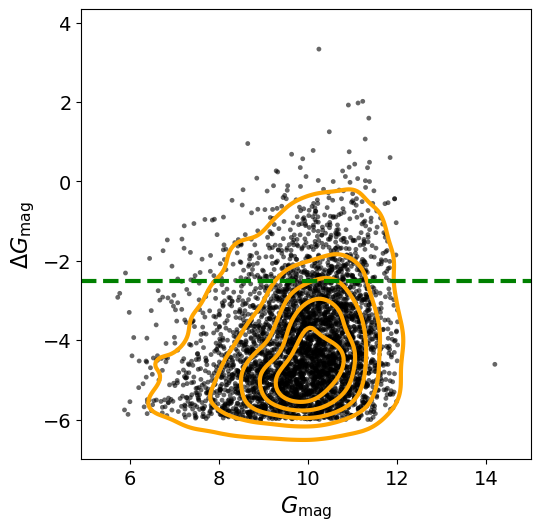

In [71]:
import seaborn as sns
# Obtener paleta accesible para daltónicos con 3 colores
palette = sns.color_palette("viridis", 12)
c1, c2, c3, c4, c5, c6, c7, c8, c9, c10, c11, c12 = palette

plt.figure(figsize=(5, 5))
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

sns.scatterplot(data=df_parental, y="delta", x="Gmag", s=12,alpha=0.6, color="black", edgecolor='none')

sns.kdeplot(
    data=df_parental, x="Gmag", y="delta",
    levels=6, color="orange", linewidths=3
)

plt.axhline(y=-2.5, color='green', linestyle='--', linewidth=3)

plt.xlabel(r'$G_{\mathrm{mag}}$', fontsize=16)
plt.ylabel(r'$\Delta G_{\mathrm{mag}}$', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("contaminants.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [74]:
df_parental = df_parental.loc[df_parental["delta"]<=-2.5].reset_index(drop=True)

In [76]:
df_parental.to_csv("catalogs/3_MassiveXTessV8_LC_DeltaMagnitude_Clean.csv",index=False)

## Guardar Curvas de luz

In [ ]:
import sys
from astropy.io import fits
def convert_to_little_endian(arr):
    # Si el array ya es little-endian, lo retornamos sin cambios
    if arr.dtype.byteorder == '<' or (arr.dtype.byteorder == '=' and sys.byteorder == 'little'):
        return arr
    # De lo contrario, cambiamos el orden de los bytes
    else:
        return arr.byteswap().newbyteorder('<')

In [ ]:
def open_LC(TIC, sector, path_download='/home/nicolas/nico/git/MassiveStarVariability/dowload_parallell/'):
    import sys
    import lightkurve as lk
    import numpy as np
    import pandas as pd

    def _to_le(arr):
        if arr.dtype.byteorder == '<' or (arr.dtype.byteorder == '=' and sys.byteorder == 'little'):
            return arr
        return arr.byteswap().newbyteorder('<')

    TIC = str(TIC).zfill(16)
    sector = str(sector).zfill(4)
    path_lc = f'hlsp_tess-spoc_tess_phot_{TIC}-s{sector}_tess_v1_lc.fits'
    lcf = lk.read(path_download+path_lc, quality_bitmask="hardest", flux_column="pdcsap_flux")
    lc = lcf.remove_nans()
    time = np.array(lc.time.value)
    flux = np.array(lc.flux.value)
    flux_err = np.array(lc.flux_err.value)

    df = pd.DataFrame({
        "Time":     _to_le(time),
        "flux":     _to_le(flux),
        "flux_err": _to_le(flux_err),
    })
    return df

In [ ]:
import ray
import os
import ast
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm

PATH_DOWNLOAD = '/home/nicolas/nico/git/MassiveStarVariability/download_paralell/'
OUT_PARQUET   = '/home/nicolas/nico/git/MassiveStarVariability/lightcurves_all.parquet'

if ray.is_initialized():
    ray.shutdown()
ray.init(num_cpus=24, ignore_reinit_error=True)

@ray.remote
def load_lc(TIC, sector, path_download=PATH_DOWNLOAD):
    try:
        df = open_LC(TIC, sector, path_download=path_download)
        df["TIC"] = int(TIC)
        df["sector"] = int(sector)
        return df
    except Exception as e:
        return f"ERROR {TIC}_{sector}: {e}"

parental_catalog = pd.read_csv("catalogs/3_MassiveXTessV8_LC_DeltaMagnitude_Clean.csv")
parental_catalog["sector_list"] = parental_catalog["sector_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
jobs = parental_catalog[["TIC", "sector_list"]].explode("sector_list").dropna()
jobs["sector_list"] = jobs["sector_list"].astype(int)
tasks = list(zip(jobs["TIC"].astype(int), jobs["sector_list"]))
print(f"Total tareas: {len(tasks)}")

# Lanza todas las tareas
futures = [load_lc.remote(tic, sec) for tic, sec in tasks]

# Consumir resultados conforme van llegando y escribir en streaming a un solo parquet
writer = None
errors = []
n_ok = 0
pending = futures
with tqdm(total=len(futures)) as pbar:
    while pending:
        done, pending = ray.wait(pending, num_returns=min(50, len(pending)))
        for res in ray.get(done):
            if isinstance(res, str):
                errors.append(res)
            else:
                table = pa.Table.from_pandas(res, preserve_index=False)
                if writer is None:
                    writer = pq.ParquetWriter(OUT_PARQUET, table.schema, compression="snappy")
                writer.write_table(table)
                n_ok += 1
            pbar.update(1)

if writer is not None:
    writer.close()

print(f"\n{n_ok} curvas escritas en {OUT_PARQUET}")
print(f"{len(errors)} errores")
if errors:
    print("Primeros:", errors[:5])

ray.shutdown()


TIC 12647534 - sector 18: 975 puntos


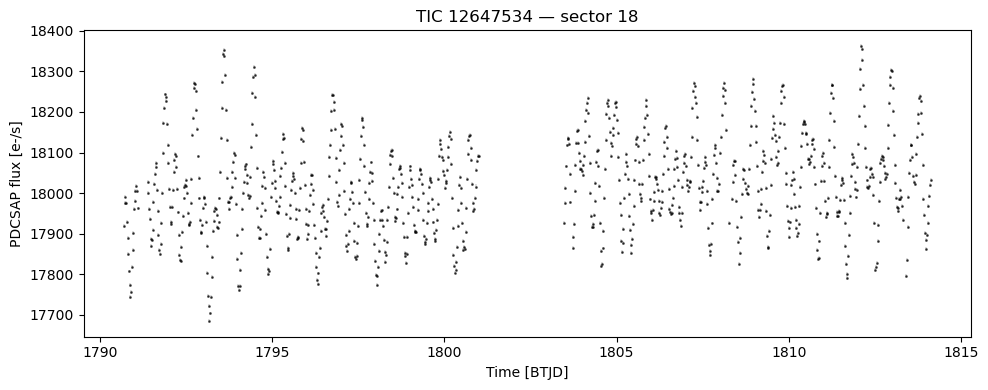

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

OUT_PARQUET = '/home/nicolas/nico/git/MassiveStarVariability/lightcurves_all.parquet'

TIC    = 12647534
sector = 18

# Lee solo las filas de ese TIC+sector (push-down filter, no carga el resto)
lc = pd.read_parquet(
    OUT_PARQUET,
    filters=[("TIC", "=", TIC), ("sector", "=", sector)],
    columns=["Time", "flux", "flux_err"],
)

print(f"TIC {TIC} - sector {sector}: {len(lc)} puntos")

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(lc["Time"], lc["flux"], yerr=lc["flux_err"],
            fmt='.', ms=2, elinewidth=0.3, color='k', alpha=0.6)
ax.set_xlabel("Time [BTJD]")
ax.set_ylabel("PDCSAP flux [e-/s]")
ax.set_title(f"TIC {TIC} — sector {sector}")
plt.tight_layout()
plt.show()
